# **Set Up**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import glob
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4


In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/birdclef_dataset/birdclef-2026"
TRAIN_AUDIO = f"{DATASET_ROOT}/train_audio"

df = pd.read_csv(f"{DATASET_ROOT}/train.csv")

df["filepath"] = df["filename"].apply(
    lambda x: os.path.join(TRAIN_AUDIO, x)
)

df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)

print(df.shape)
print("Species:", df["primary_label"].nunique())
print(df.head())

(35549, 16)
Species: 206
  primary_label secondary_labels type  latitude  longitude scientific_name  \
0       1161364               []   []  -22.7562   -46.8666    Guyalna cuta   
1       1161364               []   []  -22.7558   -46.8700    Guyalna cuta   
2       1161364               []   []  -22.7547   -46.8728    Guyalna cuta   
3       1161364               []   []  -22.7547   -46.8728    Guyalna cuta   
4       1161364               []   []  -22.7426   -46.8985    Guyalna cuta   

    common_name class_name  inat_taxon_id         author   license  rating  \
0  Guyalna cuta    Insecta        1161364  Lucas Barbosa  cc-by-nc     0.0   
1  Guyalna cuta    Insecta        1161364  Lucas Barbosa  cc-by-nc     0.0   
2  Guyalna cuta    Insecta        1161364  Lucas Barbosa  cc-by-nc     0.0   
3  Guyalna cuta    Insecta        1161364  Lucas Barbosa  cc-by-nc     0.0   
4  Guyalna cuta    Insecta        1161364  Lucas Barbosa  cc-by-nc     0.0   

                                     

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# **Dataset**

In [ ]:
species_counts = (
    df["primary_label"]
    .value_counts()
    .reset_index()
)

species_counts.columns = ["primary_label", "n_recordings"]

print(species_counts.head(50))

print("Minimum in top 30:", species_counts.head(30)["n_recordings"].min())
print("Maximum in top 30:", species_counts.head(30)["n_recordings"].max())
print("Median in top 30:", species_counts.head(30)["n_recordings"].median())

   primary_label  n_recordings
0        rubthr1           499
1         banana           498
2         fepowl           497
3        soulap1           497
4         houspa           496
5        coffal1           495
6         osprey           495
7        socfly1           494
8         compau           493
9        yeofly1           493
10        bncfly           492
11       bobfly1           492
12        trsowl           491
13        bbwduc           491
14        whtdov           491
15       sobtyr1           490
16        roahaw           489
17       strcuc1           485
18        trokin           483
19        grekis           482
20        saffin           479
21       greant1           475
22        greyel           475
23        brnowl           474
24       barant1           454
25       sofspi1           437
26       gycwor1           436
27       squcuc1           432
28       oliwoo1           424
29        limpki           405
30       compot1           368
31      

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
TOP_N = 30

top_species = species_counts.head(TOP_N)["primary_label"].tolist()

top_df = df[df["primary_label"].isin(top_species)].copy()

max_balanced_samples = top_df["primary_label"].value_counts().min()

print("Max balanced samples per species:", max_balanced_samples)

Max balanced samples per species: 405


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
N_PER_SPECIES = max_balanced_samples

In [ ]:
balanced_df = (
    top_df
    .groupby("primary_label", group_keys=False)
    .apply(lambda x: x.sample(
        n=N_PER_SPECIES,
        random_state=SEED
    ))
    .reset_index(drop=True)
)

print(balanced_df.shape)
print(balanced_df["primary_label"].value_counts())

(12150, 16)
primary_label
banana     405
barant1    405
bbwduc     405
bncfly     405
bobfly1    405
brnowl     405
coffal1    405
compau     405
fepowl     405
greant1    405
grekis     405
greyel     405
gycwor1    405
houspa     405
limpki     405
oliwoo1    405
osprey     405
roahaw     405
rubthr1    405
saffin     405
sobtyr1    405
socfly1    405
sofspi1    405
soulap1    405
squcuc1    405
strcuc1    405
trokin     405
trsowl     405
whtdov     405
yeofly1    405
Name: count, dtype: int64


/tmp/ipykernel_533/747448989.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.30,
    random_state=42,
    stratify=balanced_df["primary_label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["primary_label"]
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(8505, 16)
(1822, 16)
(1823, 16)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# **Create Mel files - 60s**

In [ ]:
import os
import torch
import torchaudio
from tqdm import tqdm

TRAIN_SAVE_DIR = "/content/drive/MyDrive/birdclef_dataset/birdclef-2026/mels_top30_405_train_12windows"
VAL_SAVE_DIR   = "/content/drive/MyDrive/birdclef_dataset/birdclef-2026/mels_top30_405_val_12windows"
TEST_SAVE_DIR  = "/content/drive/MyDrive/birdclef_dataset/birdclef-2026/mels_top30_405_test_12windows"

model_name = "top30_405_recording_cnn_maxpool"

os.makedirs(TRAIN_SAVE_DIR, exist_ok=True)
os.makedirs(VAL_SAVE_DIR, exist_ok=True)
os.makedirs(TEST_SAVE_DIR, exist_ok=True)

labels = sorted(balanced_df["primary_label"].unique())

label_to_id = {
    label: idx
    for idx, label in enumerate(labels)
}

id_to_label = {
    idx: label
    for label, idx in label_to_id.items()
}

num_classes = len(labels)

print("Classes:", num_classes)
print(label_to_id)



def audio_to_mel_windows(
    audio_path,
    sample_rate=32000,
    total_sec=60,
    window_sec=5,
    n_mels=128,
    n_fft=2048,
    hop_length=512
):
    waveform, sr = torchaudio.load(audio_path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != sample_rate:
        waveform = torchaudio.transforms.Resample(sr, sample_rate)(waveform)

    total_len = sample_rate * total_sec
    window_len = sample_rate * window_sec

    if waveform.shape[1] < total_len:
        waveform = torch.nn.functional.pad(
            waveform,
            (0, total_len - waveform.shape[1])
        )
    else:
        waveform = waveform[:, :total_len]

    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0
    )

    db_transform = torchaudio.transforms.AmplitudeToDB()

    mels = []

    for i in range(total_sec // window_sec):
        start = i * window_len
        end = start + window_len

        window = waveform[:, start:end]

        mel = mel_transform(window)
        mel = db_transform(mel)

        mels.append(mel)

    return mels


def generate_mels_from_df(df_split, save_dir, prefix):
    for idx, row in tqdm(df_split.iterrows(), total=len(df_split), desc=prefix):

        audio_path = row["filepath"]
        primary_label = row["primary_label"]
        label_id = label_to_id[primary_label]

        rec_id = idx

        first_window_path = os.path.join(
            save_dir,
            f"{prefix}_{rec_id}_window0.pt"
        )

        if os.path.exists(first_window_path):
            continue

        try:
            mels = audio_to_mel_windows(audio_path)

            for window_idx, mel in enumerate(mels):

                save_path = os.path.join(
                    save_dir,
                    f"{prefix}_{rec_id}_window{window_idx}.pt"
                )

                torch.save(
                    {
                        "mel": mel,
                        "label": label_id,
                        "primary_label": str(primary_label),
                        "source_file": audio_path,
                        "window_idx": window_idx
                    },
                    save_path
                )

        except Exception as e:
            print("Error:", audio_path, e)

Classes: 30
{'banana': 0, 'barant1': 1, 'bbwduc': 2, 'bncfly': 3, 'bobfly1': 4, 'brnowl': 5, 'coffal1': 6, 'compau': 7, 'fepowl': 8, 'greant1': 9, 'grekis': 10, 'greyel': 11, 'gycwor1': 12, 'houspa': 13, 'limpki': 14, 'oliwoo1': 15, 'osprey': 16, 'roahaw': 17, 'rubthr1': 18, 'saffin': 19, 'sobtyr1': 20, 'socfly1': 21, 'sofspi1': 22, 'soulap1': 23, 'squcuc1': 24, 'strcuc1': 25, 'trokin': 26, 'trsowl': 27, 'whtdov': 28, 'yeofly1': 29}


In [ ]:
generate_mels_from_df(train_df, TRAIN_SAVE_DIR, "train")

train: 100%|██████████| 8505/8505 [2:06:17<00:00,  1.12it/s]


In [ ]:
generate_mels_from_df(val_df, VAL_SAVE_DIR, "val")

val: 100%|██████████| 1822/1822 [27:48<00:00,  1.09it/s]


In [ ]:
generate_mels_from_df(test_df, TEST_SAVE_DIR, "test")

test: 100%|██████████| 1823/1823 [27:17<00:00,  1.11it/s]


In [ ]:
print(type(balanced_df))
print(balanced_df.shape)

<class 'pandas.core.frame.DataFrame'>
(12150, 16)


In [ ]:
import torch
import matplotlib.pyplot as plt
import os
import glob

FIG_DIR = "/content/drive/MyDrive/birdclef_dataset/report_figures_new"
os.makedirs(FIG_DIR, exist_ok=True)

In [ ]:
import glob
import re
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader

class RecordingMelDataset(Dataset):
    def __init__(self, folder):
        self.folder = folder
        self.files = sorted(glob.glob(folder + "/*.pt"))

        self.recording_to_files = defaultdict(list)

        for path in self.files:
            name = os.path.basename(path)

            match = re.match(r"(train|val|test)_(\d+)_window(\d+)\.pt", name)

            if match is None:
                raise ValueError(f"Bad filename: {name}")

            split, rec_id, window_idx = match.groups()

            self.recording_to_files[int(rec_id)].append(
                (int(window_idx), path)
            )

        self.recordings = sorted(self.recording_to_files.keys())

    def __len__(self):
        return len(self.recordings)

    def __getitem__(self, idx):
        rec_id = self.recordings[idx]

        window_paths = sorted(
            self.recording_to_files[rec_id],
            key=lambda x: x[0]
        )

        windows = []
        label = None
        primary_label = None

        for window_idx, path in window_paths:
            item = torch.load(path, map_location="cpu")

            windows.append(item["mel"].float())

            if label is None:
                label = torch.tensor(item["label"]).long()
                primary_label = item["primary_label"]

        x = torch.stack(windows)

        return x, label, primary_label

In [ ]:
val_dataset = RecordingMelDataset(VAL_SAVE_DIR)

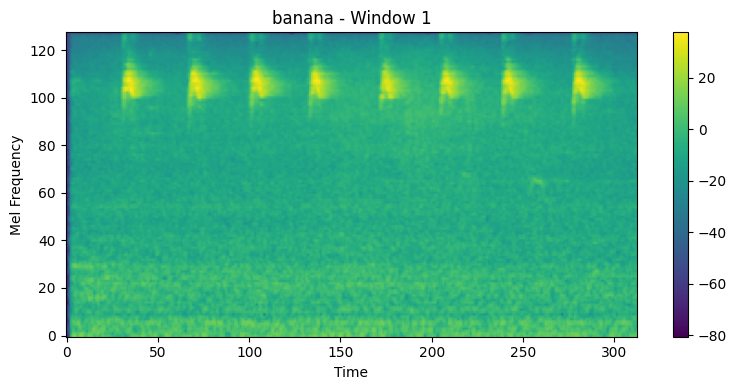

In [ ]:
x, y, label = val_dataset[0]

mel = x[0].squeeze().numpy()

plt.figure(figsize=(8,4))
plt.imshow(mel, aspect="auto", origin="lower")
plt.colorbar()
plt.title(f"{label} - Window 1")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/recording_mel_single.png", dpi=300)
plt.show()

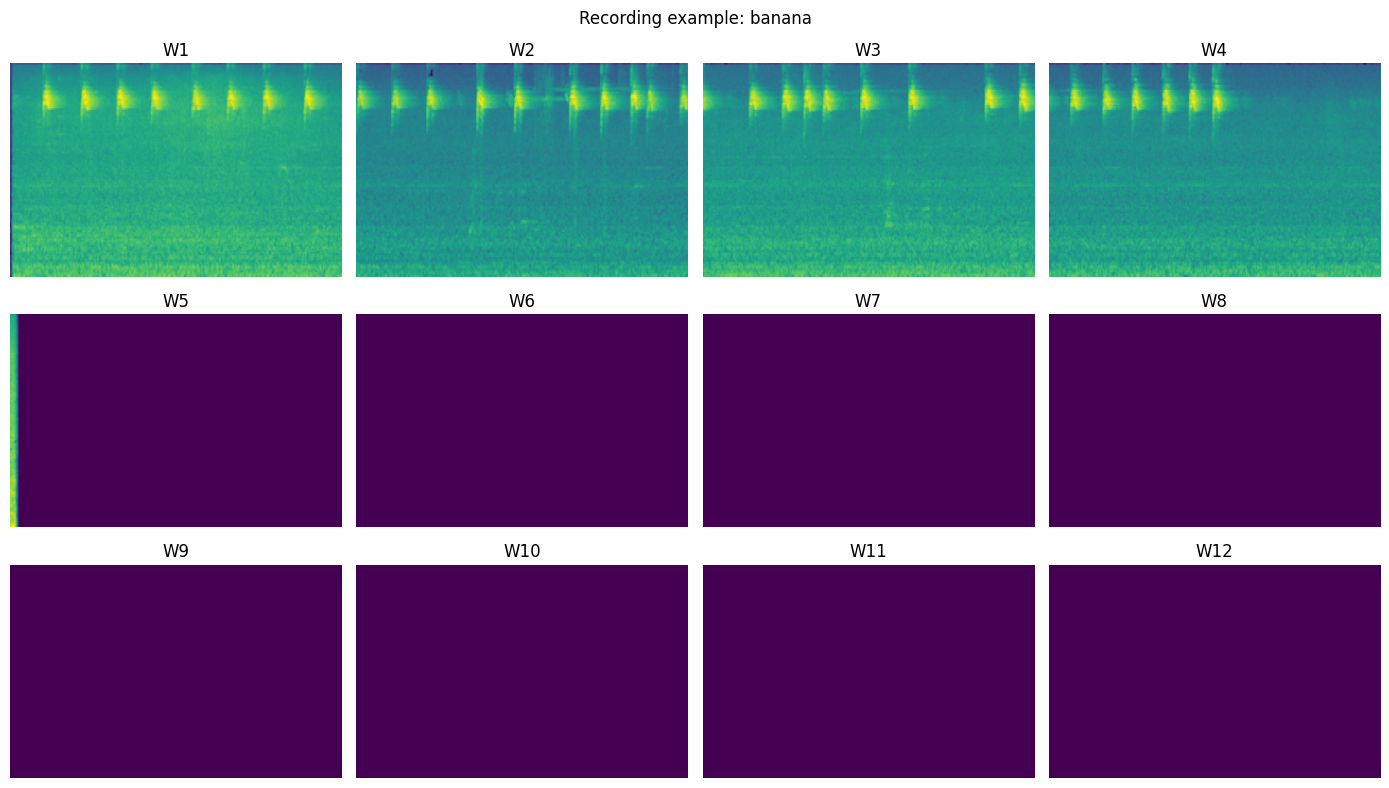

In [ ]:
x, y, label = val_dataset[0]

plt.figure(figsize=(14,8))

for i in range(12):
    plt.subplot(3,4,i+1)

    mel = x[i].squeeze().numpy()

    plt.imshow(
        mel,
        aspect="auto",
        origin="lower"
    )

    plt.title(f"W{i+1}")
    plt.axis("off")

plt.suptitle(f"Recording example: {label}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/recording_12_window_grid.png", dpi=300)
plt.show()

In [ ]:
import soundfile as sf
import numpy as np

durations = []

for fp in train_df["filepath"].head(500):

    info = sf.info(fp)

    durations.append(
        info.frames / info.samplerate
    )

print("Min:", np.min(durations))
print("Mean:", np.mean(durations))
print("Max:", np.max(durations))

Min: 0.072
Mean: 30.9829121875
Max: 946.128


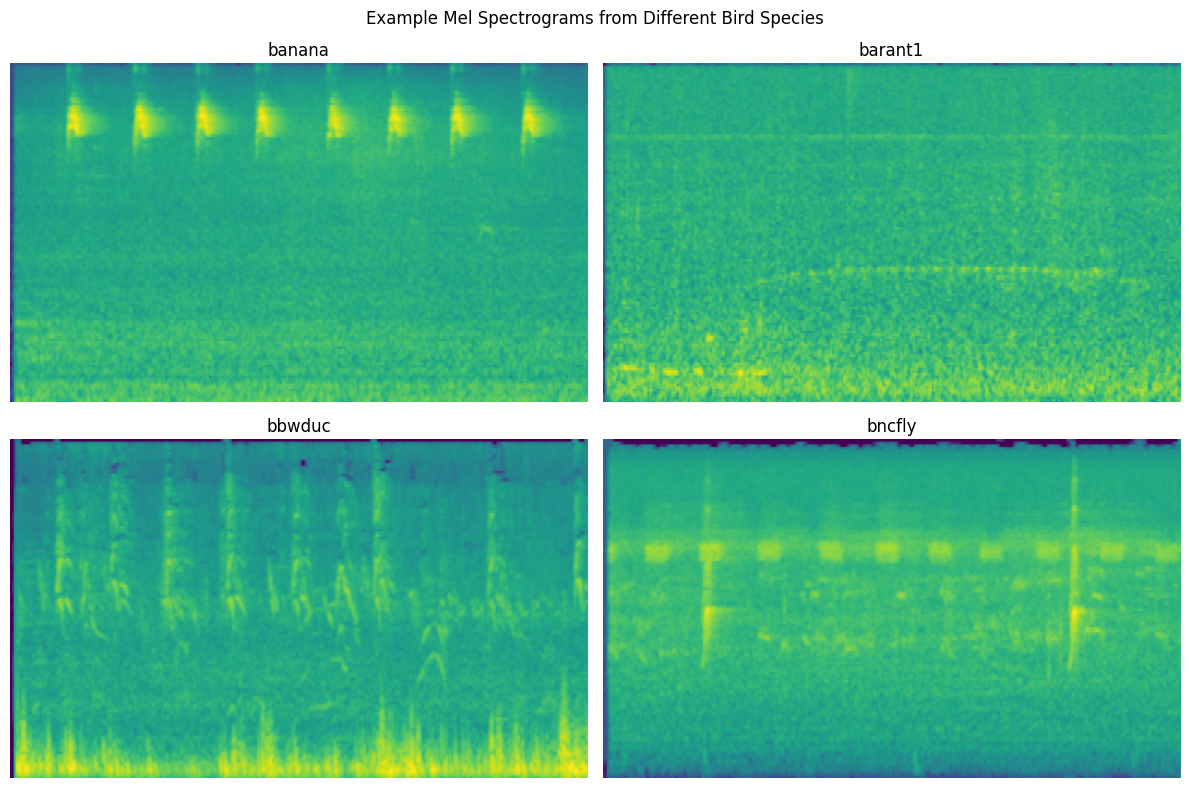

In [ ]:
species_seen = set()

plt.figure(figsize=(12,8))

plot_idx = 1

for i in range(len(val_dataset)):

    x, y, label = val_dataset[i]

    if label in species_seen:
        continue

    species_seen.add(label)

    plt.subplot(2,2,plot_idx)

    plt.imshow(
        x[0].squeeze().numpy(),
        aspect="auto",
        origin="lower"
    )

    plt.title(label)
    plt.axis("off")

    plot_idx += 1

    if plot_idx > 4:
        break

plt.suptitle("Example Mel Spectrograms from Different Bird Species")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/species_mel_examples.png", dpi=300)
plt.show()

# **Create Mel Files - 15s**

In [ ]:
import os
import torch
import torchaudio
from tqdm import tqdm

TRAIN_SAVE_DIR = "/content/drive/MyDrive/birdclef_dataset/birdclef-2026/mels_top30_405_train_3windows"
VAL_SAVE_DIR   = "/content/drive/MyDrive/birdclef_dataset/birdclef-2026/mels_top30_405_val_3windows"
TEST_SAVE_DIR  = "/content/drive/MyDrive/birdclef_dataset/birdclef-2026/mels_top30_405_test_3windows"

model_name = "top30_405_recording_cnn_maxpool_3"

os.makedirs(TRAIN_SAVE_DIR, exist_ok=True)
os.makedirs(VAL_SAVE_DIR, exist_ok=True)
os.makedirs(TEST_SAVE_DIR, exist_ok=True)

labels = sorted(balanced_df["primary_label"].unique())

label_to_id = {
    label: idx
    for idx, label in enumerate(labels)
}

id_to_label = {
    idx: label
    for label, idx in label_to_id.items()
}

num_classes = len(labels)

print("Classes:", num_classes)
print(label_to_id)



def audio_to_mel_windows(
    audio_path,
    sample_rate=32000,
    total_sec=15,
    window_sec=5,
    n_mels=128,
    n_fft=2048,
    hop_length=512
):
    waveform, sr = torchaudio.load(audio_path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != sample_rate:
        waveform = torchaudio.transforms.Resample(sr, sample_rate)(waveform)

    total_len = sample_rate * total_sec
    window_len = sample_rate * window_sec

    if waveform.shape[1] < total_len:
        waveform = torch.nn.functional.pad(
            waveform,
            (0, total_len - waveform.shape[1])
        )
    else:
        waveform = waveform[:, :total_len]

    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0
    )

    db_transform = torchaudio.transforms.AmplitudeToDB()

    mels = []

    for i in range(total_sec // window_sec):
        start = i * window_len
        end = start + window_len

        window = waveform[:, start:end]

        mel = mel_transform(window)
        mel = db_transform(mel)

        mels.append(mel)

    return mels


def generate_recording_mels_from_df(df_split, save_dir, prefix):
    for idx, row in tqdm(df_split.iterrows(), total=len(df_split), desc=prefix):

        audio_path = row["filepath"]
        primary_label = row["primary_label"]
        label_id = label_to_id[primary_label]

        rec_id = idx

        save_path = os.path.join(
            save_dir,
            f"{prefix}_{rec_id}.pt"
        )

        if os.path.exists(save_path):
            continue

        try:
            mels = audio_to_mel_windows(audio_path)

            torch.save(
                {
                    "mels": torch.stack(mels),
                    "label": label_id,
                    "primary_label": str(primary_label),
                    "source_file": audio_path,
                    "rec_id": rec_id
                },
                save_path
            )

        except Exception as e:
            print("Error:", audio_path, e)

Classes: 30
{'banana': 0, 'barant1': 1, 'bbwduc': 2, 'bncfly': 3, 'bobfly1': 4, 'brnowl': 5, 'coffal1': 6, 'compau': 7, 'fepowl': 8, 'greant1': 9, 'grekis': 10, 'greyel': 11, 'gycwor1': 12, 'houspa': 13, 'limpki': 14, 'oliwoo1': 15, 'osprey': 16, 'roahaw': 17, 'rubthr1': 18, 'saffin': 19, 'sobtyr1': 20, 'socfly1': 21, 'sofspi1': 22, 'soulap1': 23, 'squcuc1': 24, 'strcuc1': 25, 'trokin': 26, 'trsowl': 27, 'whtdov': 28, 'yeofly1': 29}


In [ ]:
generate_recording_mels_from_df(train_df, TRAIN_SAVE_DIR, "train")
generate_recording_mels_from_df(val_df, VAL_SAVE_DIR, "val")
generate_recording_mels_from_df(test_df, TEST_SAVE_DIR, "test")

test: 100%|██████████| 1823/1823 [20:54<00:00,  1.45it/s]


In [ ]:
class RecordingDatasetOneFile(Dataset):
    def __init__(self, folder):
        self.files = sorted(glob.glob(folder + "/*.pt"))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        item = torch.load(self.files[idx], map_location="cpu")

        x = item["mels"].float()
        y = torch.tensor(item["label"]).long()
        label = item["primary_label"]

        return x, y, label

In [ ]:
train_dataset = RecordingDatasetOneFile(TRAIN_SAVE_DIR)
val_dataset   = RecordingDatasetOneFile(VAL_SAVE_DIR)
test_dataset  = RecordingDatasetOneFile(TEST_SAVE_DIR)

x, y, label = train_dataset[0]

print(x.shape)
print(y)
print(label)

torch.Size([3, 1, 128, 313])
tensor(0)
banana


In [ ]:
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

x_batch, y_batch, labels_batch = next(iter(train_loader))

print(x_batch.shape)
print(y_batch.shape)

torch.Size([16, 3, 1, 128, 313])
torch.Size([16])


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

clean_path = "/content/drive/MyDrive/birdclef_dataset/birdclef-2026/train_audio_15s/test/banana/XC326973.ogg"

noisy_path = "/content/drive/MyDrive/birdclef_dataset/birdclef-2026/test_audio_15s_soundscape_noise_100/medium/banana/XC326973.ogg"

SR = 32000


clean_audio, _ = librosa.load(clean_path, sr=SR)
noisy_audio, _ = librosa.load(noisy_path, sr=SR)


clean_mel = librosa.feature.melspectrogram(
    y=clean_audio,
    sr=SR,
    n_mels=128,
    n_fft=2048,
    hop_length=512
)

noisy_mel = librosa.feature.melspectrogram(
    y=noisy_audio,
    sr=SR,
    n_mels=128,
    n_fft=2048,
    hop_length=512
)

clean_db = librosa.power_to_db(clean_mel, ref=np.max)
noisy_db = librosa.power_to_db(noisy_mel, ref=np.max)


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

img1 = librosa.display.specshow(
    clean_db,
    sr=SR,
    x_axis="time",
    y_axis="mel",
    ax=axes[0]
)
axes[0].set_title("Original Recording")

img2 = librosa.display.specshow(
    noisy_db,
    sr=SR,
    x_axis="time",
    y_axis="mel",
    ax=axes[1]
)
axes[1].set_title("Recording + Soundscape Noise")

plt.colorbar(img2, ax=axes, format="%+2.0f dB")
plt.tight_layout()
plt.show()